In [73]:
import numpy as np 
import matplotlib.pyplot as plt 
import scienceplots
plt.style.use(['science', 'notebook', 'no-latex'])

(0.0, 4.0)

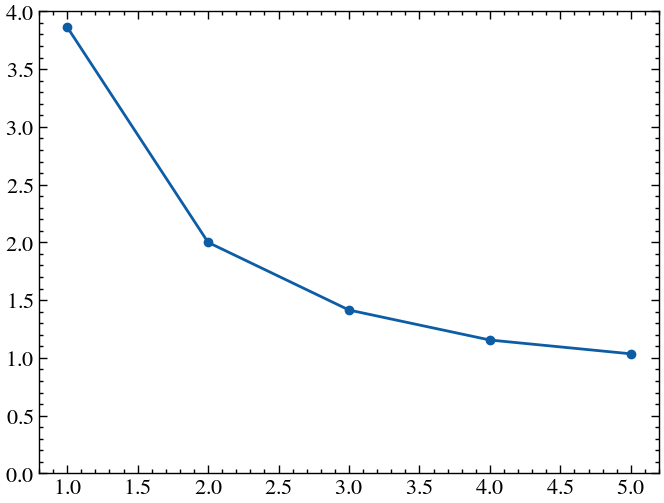

In [83]:
N = 6
n_values = np.arange(1, N, 1, dtype = float)
freqs = 1.0/np.sin(np.pi * n_values/(2*N))
plt.plot(n_values, freqs)
plt.scatter(n_values, freqs)
plt.ylim(0.0, 4.0)

In [74]:
def ssh_capacitance_matrix(N, C, Cg1, Cg2):
    main_diag = [C+Cg1+Cg2 for j in range(2*N)]
    off_diag = [-Cg1 if j%2 == 0 else -Cg2 for j in range(2*N-1)]
    mat = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
    mat[0, -1] = -Cg2
    mat[-1, 0] = -Cg2
    return mat

def ideal_inverse_matrix(N, C, Cg1, Cg2):
    main_diag = [1/(C) for j in range(2*N)]
    off_diag = [Cg1/C**2 if j%2 == 0 else Cg2/C**2 for j in range(2*N-1)]
    mat = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
    mat[0, -1] = Cg2/C**2
    mat[-1, 0] = Cg2/C**2
    return mat

In [66]:
C0 = 1.0
Cg1 = 0.5
Cg2 = 0.5
N = 3
C_1 = np.linalg.inv(ssh_capacitance_matrix(N, C0, Cg1, Cg2))

/tmp/ipykernel_11093/1578023924.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


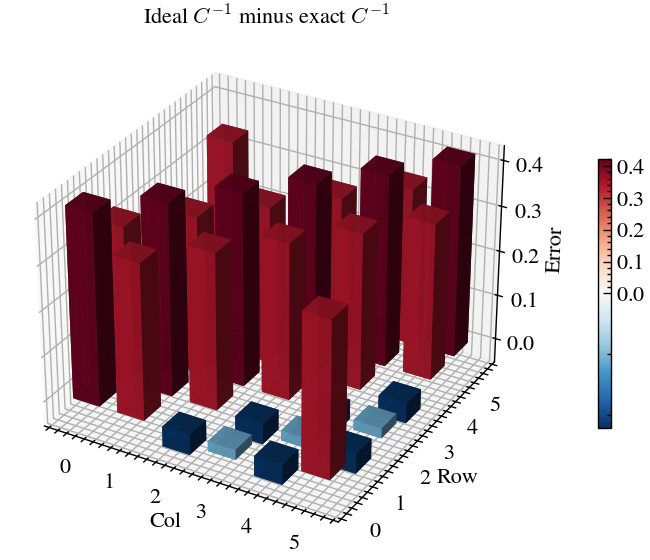

In [68]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
matrix = ideal_inverse_matrix(N, C0, Cg1, Cg2) - C_1

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(9, 7))

n = matrix.shape[0]
xpos, ypos = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
xpos = xpos.flatten()
ypos = ypos.flatten()
dz   = matrix.flatten()

# Handle negative bars: start from dz if negative, 0 if positive
zpos      = np.minimum(dz, 0)
dz_height = np.abs(dz)
dx = dy   = 0.6

# Diverging colormap centered at 0
norm   = mcolors.TwoSlopeNorm(vmin=dz.min(), vcenter=0, vmax=dz.max())
colors = cm.RdBu_r(norm(dz))

ax.bar3d(xpos - dx/2, ypos - dy/2, zpos, dx, dy, dz_height,
         color=colors, zsort="average", alpha=0.9)

ticks  = np.arange(n)
labels = [str(i) for i in range(n)]
ax.set_xticks(ticks); ax.set_xticklabels(labels)
ax.set_yticks(ticks); ax.set_yticklabels(labels)
ax.set_xlabel("Col")
ax.set_ylabel("Row")
ax.set_zlabel("Error")
ax.set_title(r"Ideal $C^{-1}$ minus exact $C^{-1}$")

# Colorbar
sm = cm.ScalarMappable(cmap=cm.RdBu_r, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11093/604330581.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


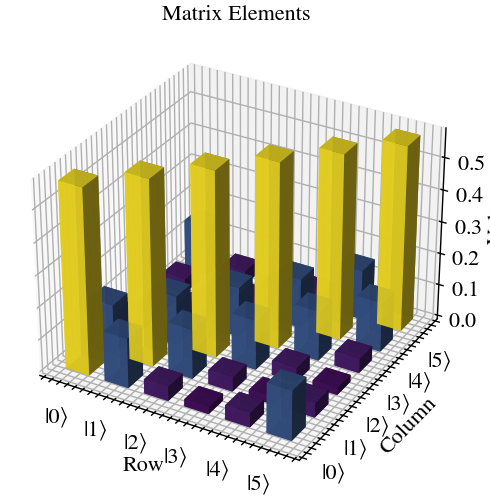

In [69]:
matrix = C_1/C0

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))

n = matrix.shape[0]
xpos, ypos = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dz = matrix.flatten()
dx = dy = 0.6  # bar width

# Color by value
colors = plt.cm.viridis(dz / dz.max())

ax.bar3d(xpos - dx/2, ypos - dy/2, zpos, dx, dy, dz,
         color=colors, zsort="average", alpha=0.9)

ticks = np.arange(n)
labels = [f"|{i}⟩" for i in range(n)]
ax.set_xticks(ticks); ax.set_xticklabels(labels)
ax.set_yticks(ticks); ax.set_yticklabels(labels)
ax.set_xlabel("Row")
ax.set_ylabel("Column")
ax.set_zlabel("Value")
ax.set_title("Matrix Elements")

plt.tight_layout()
plt.show()

In [70]:
probe = np.array(
    [
        [1, -1, 0, 0],
        [0, 0, 1, -1],
        [0, -1, 1, 0],
        [1, 1, 1, 1]
    ]
)

In [72]:
np.linalg.det(probe)

np.float64(3.999999999999999)